# 안녕하세요^^ 
# AIVLE 미니 프로젝트에 오신 여러분을 환영합니다.
* 본 과정에서는 실제 사례와 데이터를 기반으로 문제를 해결하는 전체 과정을 자기 주도형 실습으로 진행해볼 예정입니다.
* 앞선 교육과정을 정리하는 마음과 지금까지 배운 내용을 바탕으로 문제 해결을 해볼게요!
* 미니 프로젝트를 통한 문제 해결 과정 'A에서 Z까지', 지금부터 시작합니다!

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---

# (실습준비) 데이터 불러오기부터

In [248]:
import pandas as pd

# 학습/평가 데이터 로딩
train_x = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/aivle/5차미니프로젝트-개인/train_x.csv")
train_y = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/aivle/5차미니프로젝트-개인/train_y.csv")
test_x = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/aivle/5차미니프로젝트-개인/test_x.csv")
test_y = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/aivle/5차미니프로젝트-개인/test_y.csv")

In [247]:
test_x

,hour,년,월,일,2m,1d,2m_mean,1h,1m
0,1,2022,3,1,30759.5067,32446.9396,35051.139387,32000.2302,37214.1462
1,2,2022,3,1,31048.8787,32641.7149,35052.231073,32175.7958,36191.5288
2,3,2022,3,1,31076.1092,32752.8852,35053.426337,32594.7053,34930.4409
3,4,2022,3,1,31714.9309,33477.6377,35054.773135,32768.6036,33477.5592
4,5,2022,3,1,33368.3456,34733.7273,35055.961078,33621.9971,33033.3201
...,...,...,...,...,...,...,...,...,...
2922,19,2022,6,30,34399.1478,31689.8212,37846.469234,34644.2246,41039.1758
2923,20,2022,6,30,33072.9047,30425.9054,37845.015671,32969.6040,41457.5241
2924,21,2022,6,30,32823.1442,30352.8869,37843.673967,31014.6597,41644.5315
2925,22,2022,6,30,32271.0565,30232.2846,37842.429963,30923.2923,41273.2997


In [249]:
a=list(train_x)

In [250]:
train_x = train_x.values
train_y = train_y.values
test_x = test_x.values
test_y = test_y.values

---

# 1. Machine Learning
## 이제 모델링을 해봅시다!
+ KeyPoint : 머신러닝 라이브러리를 토대로 모델링을 할 수 있다.

In [165]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.rc('font', family='Malgun Gothic')
sns.set(font="Malgun Gothic",#"NanumGothicCoding", 
        rc={"axes.unicode_minus":False}, # 마이너스 부호 깨짐 현상 해결
        style='darkgrid')

### 가. LinearRegression 부터 시작해봅시다.

#### [실습문제1] 머신러닝_1
* Train과 Test로 나눈 데이터를 기준으로 LinearRegression 모델링을 진행하고 평가를 해주세요.
* 성능지표 : RMSE, R-squared Score

In [251]:
# 아래에 실습코드를 작성하세요.
from sklearn.linear_model import LinearRegression
from sklearn.metrics import * 

In [252]:
# 아래에 실습코드를 작성하세요.
linear=LinearRegression()
linear.fit(train_x,train_y)
linear_predict=linear.predict(test_x)

In [253]:
# 아래에 실습코드를 작성하세요.
print('RMSE : ', mean_squared_error(test_y, linear_predict, squared = False))
print('R2score  : ', r2_score(test_y, linear_predict))

RMSE :  818.0968510981577
R2score  :  0.946957512262454


### 나. 다음은 앙상블 기법을 토대로 랜덤포레스트와 그라디언부스팅을 활용해봅시다.

#### 1) 렌덤포레스트
##### 배깅의 일종으로 의사결정나무(Decision Tree) 여러 개를 모아서 숲을 랜덤으로 구성하고 이를 종합해서 최종 모델을 산출하는 기법이라고 할 수 있다.

#### [실습문제2] 머신러닝_2
* Train과 Test로 나눈 데이터를 기준으로 렌덤포레스트로 모델을 학습을 진행하고 평가를 해주세요.
* 성능지표 : RMSE, R-squared Score

In [182]:
# 아래에 실습코드를 작성하세요.
from sklearn.ensemble import RandomForestRegressor
params={'n_estimators': range(60,200,10),'max_features':range(1,7,2)}
rf=RandomForestRegressor()
rf_gs=GridSearchCV(rf,params,cv=5,verbose=3)
rf_gs.fit(train_x,train_y)
rf_predict=rf_gs.predict(test_x)

Fitting 5 folds for each of 42 candidates, totalling 210 fits


/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_validation.py:680: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)


[CV 1/5] END ...max_features=1, n_estimators=60;, score=0.908 total time=   2.7s


/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_validation.py:680: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)


[CV 2/5] END ...max_features=1, n_estimators=60;, score=0.852 total time=   2.2s


...

/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_validation.py:680: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)


[CV 4/5] END ..max_features=5, n_estimators=190;, score=0.960 total time=  22.9s


/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_validation.py:680: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  estimator.fit(X_train, y_train, **fit_params)


[CV 5/5] END ..max_features=5, n_estimators=190;, score=0.944 total time=  23.0s


/usr/local/lib/python3.7/dist-packages/sklearn/model_selection/_search.py:926: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  self.best_estimator_.fit(X, y, **fit_params)


In [183]:
# 아래에 실습코드를 작성하세요.
print('RMSE : ', mean_squared_error(test_y, rf_predict, squared = False))
print('R2score  : ', r2_score(test_y, rf_predict))

RMSE :  684.5101288796217
R2score  :  0.9679396678807323


#### [실습문제3] 머신러닝_3
* 렌덤포레스트로 학습한 모델의 feature_importances 또는 Shap value를 구해보세요.
* 확인할 수 있는 내용으로 우리 모델에서의 인사이트를 정리해보세요.

In [24]:
# Feature의 중요도 확인
# 변수 중요도 plot
def plot_feature_importance(importance, names, topn = 'all'):
    feature_importance = np.array(importance)
    feature_names = np.array(names)

    data={'feature_names':feature_names,'feature_importance':feature_importance}
    fi_temp = pd.DataFrame(data)

    fi_temp.sort_values(by=['feature_importance'], ascending=False,inplace=True)
    fi_temp.reset_index(drop=True, inplace = True)

    if topn == 'all' :
        fi_df = fi_temp.copy()
    else :
        fi_df = fi_temp.iloc[:topn]

    plt.figure(figsize=(10,8))
    sns.barplot(x='feature_importance', y='feature_names', data = fi_df)

    plt.xlabel('importance')
    plt.ylabel('feature names')
    plt.grid()

    return fi_df



In [33]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
import numpy as np
from sklearn.inspection import permutation_importance

/usr/local/lib/python3.7/dist-packages/matplotlib/backends/backend_agg.py:214: RuntimeWarning: Glyph 51068 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/usr/local/lib/python3.7/dist-packages/matplotlib/backends/backend_agg.py:214: RuntimeWarning: Glyph 50900 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/usr/local/lib/python3.7/dist-packages/matplotlib/backends/backend_agg.py:183: RuntimeWarning: Glyph 51068 missing from current font.
  font.set_text(s, 0, flags=flags)
/usr/local/lib/python3.7/dist-packages/matplotlib/backends/backend_agg.py:183: RuntimeWarning: Glyph 50900 missing from current font.
  font.set_text(s, 0, flags=flags)


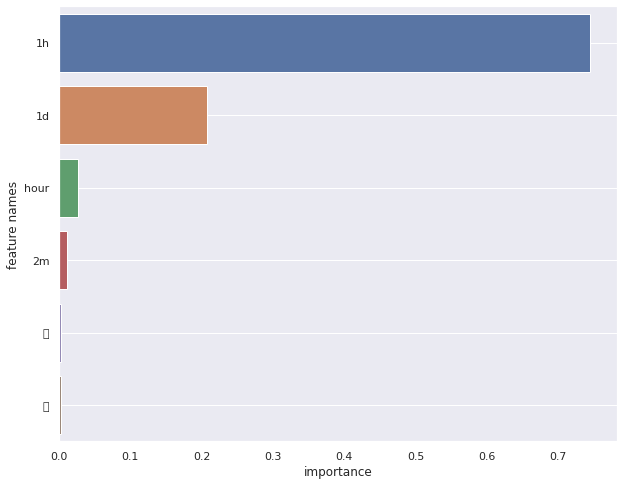

In [186]:
result = plot_feature_importance(rf_gs.best_estimator_.feature_importances_, a, 6)

In [ ]:
# 확인할 수 있는 인사이트
# 1.
# 2.
# 3.

#### 2) GradientBoosting
##### 앞선 모델의 에러를 다음 모델의 예측 값으로 활용하면서 가중치 업데이트 하는데 경사하강법(Gradient Descent)를 활용해서 최적 모델을 만드는 기법

#### [실습문제4] 머신러닝_4
* Train과 Test로 나눈 데이터를 기준으로 그라디언트부스팅으로 모델을 학습을 진행하고 평가를 해주세요.
* 성능지표 : RMSE, R-squared Score

In [254]:
# 아래에 실습코드를 작성하세요.
from sklearn.ensemble import GradientBoostingRegressor

gb=GradientBoostingRegressor()
gb.fit(train_x,train_y)
gb_predict=gb.predict(test_x)

/usr/local/lib/python3.7/dist-packages/sklearn/ensemble/_gb.py:494: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [255]:
# 아래에 실습코드를 작성하세요.
# 아래에 실습코드를 작성하세요.
print('RMSE : ', mean_squared_error(test_y, gb_predict, squared = False))
print('R2score  : ', r2_score(test_y, gb_predict))

RMSE :  766.2408993854698
R2score  :  0.9534687090656633


#### [실습문제5] 머신러닝_5
* 그라디언트부스팅으로 학습한 모델의 feature_importances 또는 Shap value를 구해보세요.
* 확인할 수 있는 내용으로 우리 모델에서의 인사이트를 정리해보세요.

In [ ]:
# Feature의 중요도 확인




In [ ]:
# 확인할 수 있는 인사이트
# 1.
# 2.
# 3.

#### 3) Self Choice Model
##### 앞선 교육과정에서 배운 머신러닝 모델 중 어떤 것이든 좋습니다. 원하는 모델을 선택해서 학습을 시켜보세요.

#### [실습문제6] 머신러닝_6
* Train과 Test로 나눈 데이터를 기준으로 Self Choice Model로 모델을 학습을 진행하고 평가를 해주세요.
* 성능지표 : RMSE, R-squared Score

In [145]:
# 아래에 실습코드를 작성하세요.
from sklearn.svm import SVC,SVR
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from xgboost import XGBRegressor

In [234]:
# 아래에 실습코드를 작성하세요.
parmas={'max_depth':range(5,7,1),'n_estimators':range(100,120,10),'learning_rate':[0.1,0.2,0.3]}
xgb=XGBRegressor()
xgb_gs=GridSearchCV(xgb,parmas)
xgb_gs.fit(train_x,train_y)
xgb_predict=xgb_gs.predict(test_x)

[07:55:24] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[07:55:27] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[07:55:31] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[07:55:34] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[07:55:37] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[07:55:40] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[07:55:44] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.
[07:55:47] WARNING: /workspace/src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of re

In [235]:
# 아래에 실습코드를 작성하세요.
print('RMSE : ', mean_squared_error(test_y, xgb_predict, squared = False))
print('R2score  : ', r2_score(test_y, xgb_predict))

RMSE :  686.2918227785294
R2score  :  0.9677725526372203


In [236]:
xgb_gs.best_params_

{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 110}

In [237]:
import joblib
joblib.dump(xgb_gs,'/content/drive/MyDrive/Colab Notebooks/aivle/5차미니프로젝트-개인/model/xgb.pkl')

['/content/drive/MyDrive/Colab Notebooks/aivle/5차미니프로젝트-개인/model/xgb.pkl']

#### [실습문제7] 머신러닝_7
* Self Choice Model로 학습한 모델의 feature_importances 또는 Shap value를 구해보세요.
* 확인할 수 있는 내용으로 우리 모델에서의 인사이트를 정리해보세요.

In [ ]:
# Feature의 중요도 확인




In [ ]:
# 확인할 수 있는 인사이트
# 1.
# 2.
# 3.

#### [실습문제8] 스케일링
* Min Max Scale 함수를 활용하여 스케일링 후 위 모델에 적용하여 보세요. 


In [125]:
# 아래에 실습코드를 작성하세요.
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
train_x_s=scaler.fit_transform(train_x)
test_x_s=scaler.transform(test_x)

In [ ]:
# 아래에 실습코드를 작성하세요.



---

# 2. Deep Learning 
## 이번엔 딥러닝 모델링을 해봅시다.

#### [실습문제9] 딥러닝

* tensorflow 라이브러리를 활용한 모델을 자유롭게 만들어보세요.

In [199]:
# 아래에 실습코드를 작성하세요.
import tensorflow as tf
from tensorflow import keras

In [256]:
train_x.shape

(43513, 9)

In [257]:
# 아래에 실습코드를 작성하세요.
keras.backend.clear_session()

dl=keras.models.Sequential()
dl.add(keras.layers.Input(shape=(9,)))
dl.add(keras.layers.Dense(256,activation='swish'))
dl.add(keras.layers.Dense(128,activation='swish'))
dl.add(keras.layers.Dense(1))

dl.compile(loss='mse',optimizer='adam')
dl.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               2560      
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dense_2 (Dense)             (None, 1)                 129       
                                                                 
Total params: 35,585
Trainable params: 35,585
Non-trainable params: 0
_________________________________________________________________


In [213]:
from tensorflow.keras.callbacks import EarlyStopping
es=EarlyStopping(monitor='val_loss',
                 min_delta=0,
                 patience=5,
                 verbose=1,
                 restore_best_weights=True)

In [258]:
# 아래에 실습코드를 작성하세요.
dl.fit(train_x,train_y,epochs=100, validation_split=0.2,callbacks=[es])

Epoch 1/100
1088/1088 [==============================] - 3s 2ms/step - loss: 5002752.0000 - val_loss: 570612.2500
Epoch 2/100
1088/1088 [==============================] - 3s 2ms/step - loss: 1034129.8750 - val_loss: 601432.0000
Epoch 3/100
1088/1088 [==============================] - 3s 3ms/step - loss: 1045051.0625 - val_loss: 548180.1875
Epoch 4/100
1088/1088 [==============================] - 3s 3ms/step - loss: 1028533.0000 - val_loss: 662839.1875
Epoch 5/100
1088/1088 [==============================] - 3s 2ms/step - loss: 1037846.5000 - val_loss: 599660.8125
Epoch 6/100
1088/1088 [==============================] - 2s 2ms/step - loss: 990053.6875 - val_loss: 576919.6875
Epoch 7/100
1088/1088 [==============================] - 2s 2ms/step - loss: 969309.1875 - val_loss: 624519.6875
Epoch 8/100
1088/1088 [==============================] - 3s 3ms/step - loss: 959505.5000 - val_loss: 547396.0625
Epoch 9/100
1088/1088 [==============================] - 3s 2ms/step - loss: 929116.0625 - 

In [259]:
0.# 아래에 실습코드를 작성하세요.
dl_predict=dl.predict(test_x)
print('RMSE : ', mean_squared_error(test_y, dl_predict, squared = False))
print('R2score  : ', r2_score(test_y, dl_predict))

136/136 [==============================] - 0s 1ms/step
RMSE :  802.3385937417925
R2score  :  0.9489812506311361


In [ ]:
# 아래에 실습코드를 작성하세요.


In [ ]:
# 아래에 실습코드를 작성하세요.



## 정리

1. 스케일링 시 성능 하락
2. 총생활인구 drop, 성별나이 살리면 성능 0.95까지 나옴
3. 튜토리얼시 최고 성능 0.72
4. 총생활인구 y, 1d,1h,2m x  최고성능 Gradient Boosting 0.96
5. 총생활인구 y, 1d,1h,2m,1m,2m_mean x  최고성능 Gradient Boosting 0.96 model save